In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [2]:
import pandas as pd
import joblib
from src.explain import *

In [3]:
# Load data
PATH = "../data/"
test_df = pd.read_csv(PATH + "train_msmes_data.csv")
train_df = pd.read_csv(PATH + "test_msmes_data.csv")

X_train = train_df.drop(columns = ["Default"])
X_test = test_df.drop(columns = ["Default"])

#load pipeline
PIPELINE_FILE = "../models/financial_health_xgboost_pipeline.pkl"
pipeline = joblib.load(PIPELINE_FILE)

explainer, shap_values, X_processed, feature_names = compute_shap(pipeline, X_train)

In [4]:
explanation_df = explain_customer(shap_values, feature_names, index = 0)

explanation_df

,feature,shap_value
0,GST_Compliance_Rate,2.522361
1,GST_Filing_Delay,2.223978
2,Business_Age,-2.147262
3,Cashflow_Volatility,-1.599893
4,EMI_Bounce_Count,-1.094059
5,Digital_Sales_Ratio,1.024546
6,Vendor_Payment_Delay,0.646379
7,Average_Bank_Balance,-0.307322
8,Monthly_GST_Sales,-0.262091
9,Monthly_UPI_Count,0.165247


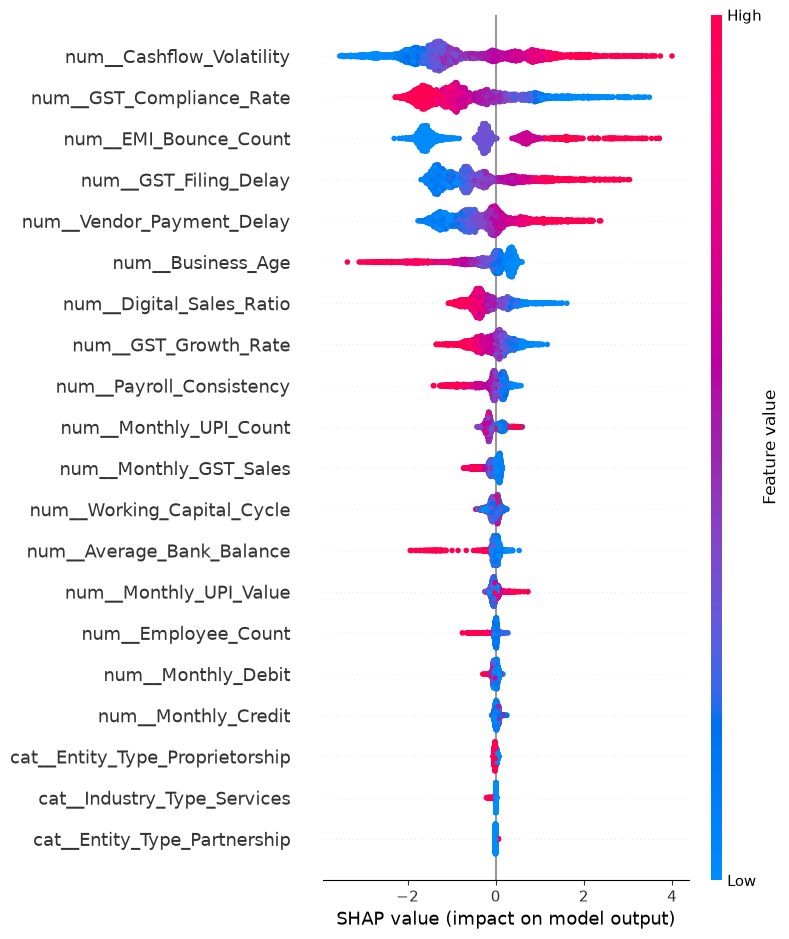

In [5]:
plot_shap(
    explainer,
    X_processed,
    shap_values,
    feature_names,
    plot_type="summary"
)

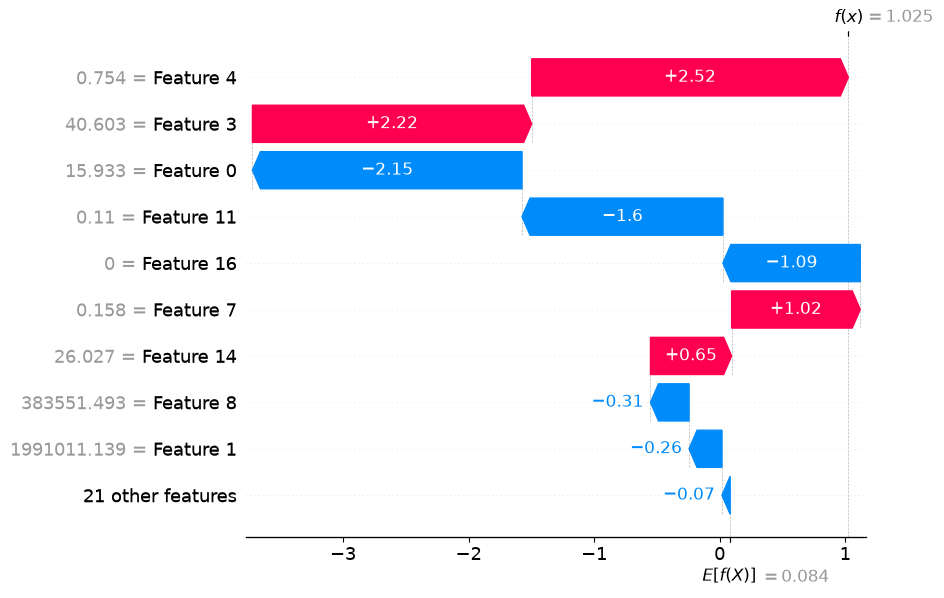

In [6]:
plot_shap(
    explainer,
    X_processed,
    shap_values,
    feature_names,
    plot_type="waterfall",
    index=0
)

In [7]:
shap_values.shape

(4000, 30)

In [8]:
global_importance = np.abs(shap_values).mean(axis=0)
global_importance

array([0.4527232 , 0.12088174, 0.29930344, 0.8817143 , 1.0357668 ,
       0.15818655, 0.06274915, 0.3911697 , 0.07526179, 0.03266455,
       0.04010407, 1.2823364 , 0.04209866, 0.21968217, 0.64670867,
       0.0819713 , 1.0276024 , 0.        , 0.00149081, 0.00132654,
       0.00358223, 0.00358275, 0.        , 0.00221249, 0.01090352,
       0.00187612, 0.00376989, 0.00899842, 0.00383537, 0.02103719],
      dtype=float32)

In [9]:
feature_map = [
    f.split("__", 1)[1] if "__" in f else f
    for f in feature_names
]

importance_df = pd.DataFrame({
    "feature": feature_map,
    "importance": np.abs(shap_values).mean(axis=0)
})

importance_df = (
    importance_df
    .groupby("feature", as_index=False)
    .sum()
)

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

importance_df

,feature,importance
5,Cashflow_Volatility,1.282336
13,GST_Compliance_Rate,1.035767
7,EMI_Bounce_Count,1.027602
14,GST_Filing_Delay,0.881714
28,Vendor_Payment_Delay,0.646709
1,Business_Age,0.452723
6,Digital_Sales_Ratio,0.391170
15,GST_Growth_Rate,0.299303
27,Payroll_Consistency,0.219682
25,Monthly_UPI_Count,0.158187


In [10]:
DIMENSIONS = {
    "cash_flow": ["Monthly_GST_Sales", "Average_Bank_Balance", "Monthly_Credit", 
                  "Monthly_Debit", "GST_Growth_Rate","Cashflow_Volatility"],
    
    "compliance": ["GST_Compliance_Rate", "GST_Filing_Delay"],
    
    "operational": ["Payroll_Consistency","Vendor_Payment_Delay","Working_Capital_Cycle"],
    
    "digital": ["Monthly_UPI_Count", "Monthly_UPI_Value", "Digital_Sales_Ratio"],
    
    "stability": ["Business_Age", "Employee_Count"]
}


dimension_weights = {}

for dimension, features in DIMENSIONS.items():

    score = importance_df[
        importance_df.feature.isin(features)
    ]["importance"].sum()

    dimension_weights[dimension] = score

    
# Normalize weight
total = sum(dimension_weights.values())

for k in dimension_weights:
    dimension_weights[k] = float(dimension_weights[k] / total)
    dimension_weights[k] = round(dimension_weights[k], 3)

In [11]:
dimension_weights

{'cash_flow': 0.318,
 'compliance': 0.329,
 'operational': 0.163,
 'digital': 0.105,
 'stability': 0.085}

In [12]:
import json
with open("../models/shap_dimension_weights.json", "w") as file:
    json.dump(dimension_weights, file, indent = 4)